## **Homework 02 - Stock Markets Analytics -  Zoomcamp 2026**

In [88]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np

from io import StringIO

## **Question 01**

- **Problem statement: What is the total withdrawn IPO value (in $ millions) for the company class with the highest total withdrawal value?**

### **Solution**

In [89]:
url = f"https://www.iposcoop.com/ipos-recently-filed"
headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/58.0.3029.110 Safari/537.3'
        )
    }

response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()

In [90]:
html_io = StringIO(response.text)
tables = pd.read_html(html_io)

for table in tables:
    display(table)

,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating
0,2026-09-28,Encore Medical Inc.,EMI,The Oak Ridge Financial Services Group/Network...,3.0,$5.00,$5.00,$15.00,Wednesday,S/O
1,2026-09-25,Elevation Acquisition Group,ELEVU,Maxim Group,10.0,$10.00,$10.00,$100.00,TBA,S/O
2,2026-09-25,Holtec Nuclear (Withdrawn),HNUC,J.P.Morgan/Guggenheim Securities/Goldman Sachs...,50.0,$15.00,$18.00,$825.00,Withdrawn,S/O
3,2026-09-25,RegenLab USA,RGNA,StoneX,0.0,NaN,NaN,$35.00,TBA,S/O
4,2026-09-25,TCGX Acquisition Corp. II (Stock-Only),TCXB,Guggenheim Securities,10.0,$10.00,$10.00,$100.00,TBA,S/O
...,...,...,...,...,...,...,...,...,...,...
495,2026-01-06,"Altech Digital Co., Ltd.",ALD,Pacific Century Securities/Revere Securities,1.5,$4.00,$4.00,$6.00,Withdrawn,S/O
496,2026-01-06,Soren Acquisition Corp.,SORNU,BTIG,22.0,$10.00,$10.00,$220.00,Priced,S/O
497,2026-01-05,Art Technology Acquisition Corp.,ARTCU,Clear Street,22.0,$10.00,$10.00,$220.00,Priced,S/O
498,2026-01-05,Black Spade Acquisition III Co.,BIIIU,Cohen & Company Capital Markets/Chardan,15.0,$10.00,$10.00,$150.00,Priced,S/O


In [91]:
df_ipos = tables[0]

In [92]:
df_ipos["Expected To Trade"].value_counts()

Expected To Trade
Priced       267
TBA          178
Withdrawn     35
Week of        7
Wednesday      5
Postponed      3
Thursday       2
Monday         1
Tuesday        1
Friday         1
Name: count, dtype: int64

In [93]:
df_ipos.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   File Date             500 non-null    str    
 1   Company               500 non-null    str    
 2   Symbol                500 non-null    str    
 3   Managers              500 non-null    str    
 4   Shares (millions)     500 non-null    float64
 5   Price Low             464 non-null    str    
 6   Price High            464 non-null    str    
 7   Est $ Vol (millions)  495 non-null    str    
 8   Expected To Trade     500 non-null    str    
 9   SCOOP Rating          500 non-null    str    
dtypes: float64(1), str(9)
memory usage: 92.5 KB


In [94]:
is_withdrawn = df_ipos["Expected To Trade"] == "Withdrawn"
is_before_cutoff = pd.to_datetime(df_ipos["File Date"]) < "2026-09-11"

df_withdrawn = df_ipos[is_withdrawn & is_before_cutoff].reset_index(drop=True)
df_withdrawn.shape

(31, 10)

In [95]:
COMPANY_TYPE_RULES = [  
    ("Technologies",     ["Technologies"]),
    ("Acquisition Corp", ["Acquisition Corp", "Acquisition Corporation", "Corp"]),
    ("Inc.",             ["Inc", "Incorporated"]),
    ("Group",            ["Group"]),
    ("Limited",          ["Ltd", "Limited"]),
    ("Holdings",         ["Holdings", "Holding"]),
    ("Other",          ["Others"])
]

def classify_company(name):
    for company_type, patterns in COMPANY_TYPE_RULES:
        if any(p in name for p in patterns):
            return company_type
    return "Other"

df_withdrawn["Company Type"] = df_withdrawn["Company"].apply(classify_company)
df_withdrawn["Company Type"].value_counts()


Company Type
Other               8
Limited             7
Acquisition Corp    5
Holdings            4
Technologies        3
Group               3
Inc.                1
Name: count, dtype: int64

In [96]:
df_withdrawn["Price Low"] = pd.to_numeric(df_withdrawn["Price Low"].str.replace("$", ""), errors='coerce')
df_withdrawn["Price High"] = pd.to_numeric(df_withdrawn["Price High"].str.replace("$", ""), errors='coerce')

In [97]:
df_withdrawn["Avg_price"] = (df_withdrawn["Price High"] + df_withdrawn["Price Low"]) / 2

df_withdrawn[["Symbol", "Company Type", "Price High", "Price Low", "Avg_price", "Est $ Vol (millions)"]]

,Symbol,Company Type,Price High,Price Low,Avg_price,Est $ Vol (millions)
0,MTVE,Technologies,NaN,NaN,NaN,$100.00
1,IDTL,Holdings,5.0,4.0,4.50,$9.00
2,HOS,Other,NaN,NaN,NaN,$100.00
3,CBAI,Technologies,5.0,4.0,4.50,$22.50
4,TMRDU,Acquisition Corp,10.0,10.0,10.00,$200.00
5,BLEUU,Acquisition Corp,10.0,10.0,10.00,$125.00
6,LHI,Other,6.0,4.0,5.00,$19.00
7,NCLA,Other,10.0,8.0,9.00,$50.40
8,APEX,Limited,4.0,4.0,4.00,$15.00
9,CDN,Holdings,4.5,4.0,4.25,$15.94


In [98]:
df_withdrawn["Shares (millions)"] = pd.to_numeric(df_withdrawn["Shares (millions)"].astype(str).str.replace("$", ""), errors='coerce')
df_withdrawn["Est $ Vol (millions)"] = pd.to_numeric(df_withdrawn["Est $ Vol (millions)"].astype(str).str.replace("$", ""), errors='coerce')

In [99]:
df_withdrawn.isnull().sum()

File Date               0
Company                 0
Symbol                  0
Managers                0
Shares (millions)       0
Price Low               6
Price High              6
Est $ Vol (millions)    0
Expected To Trade       0
SCOOP Rating            0
Company Type            0
Avg_price               6
dtype: int64

In [100]:
df_withdrawn_clean = df_withdrawn.copy()
df_withdrawn_clean.head()

,File Date,Company,Symbol,Managers,Shares (millions),Price Low,Price High,Est $ Vol (millions),Expected To Trade,SCOOP Rating,Company Type,Avg_price
0,2026-09-10,Motive Technologies (Withdrawn),MTVE,J.P.Morgan/Citigroup/Barclays/Jefferies/RBC Ca...,0.0,NaN,NaN,100.0,Withdrawn,S/O,Technologies,NaN
1,2026-09-04,Idea Tech Holding (Withdrawn),IDTL,R.F. Lafferty & Co.,2.0,4.0,5.0,9.0,Withdrawn,S/O,Holdings,4.5
2,2026-09-01,Hornbeck Offshore Services (Withdrawn),HOS,J.P. Morgan/ Barclays/DNB Markets/Piper Sandle...,0.0,NaN,NaN,100.0,Withdrawn,S/O,Other,NaN
3,2026-08-31,Coolbit Technologies Ltd. (Withdrawn),CBAI,Eddid Securities USA,5.0,4.0,5.0,22.5,Withdrawn,S/O,Technologies,4.5
4,2026-08-27,Timber Road Acquisition Corp. (Withdrawn),TMRDU,Roth Capital Partners/Stone X Financial Inc.,20.0,10.0,10.0,200.0,Withdrawn,S/O,Acquisition Corp,10.0


In [101]:
df_withdrawn_clean["Shares_offered_value"] = (
    df_withdrawn_clean["Shares (millions)"] * df_withdrawn_clean["Avg_price"]
).fillna(df_withdrawn_clean["Est $ Vol (millions)"])

df_withdrawn_clean[["Company", "Shares (millions)", "Avg_price", "Est $ Vol (millions)", "Shares_offered_value"]]

,Company,Shares (millions),Avg_price,Est $ Vol (millions),Shares_offered_value
0,Motive Technologies (Withdrawn),0.00,NaN,100.00,100.0000
1,Idea Tech Holding (Withdrawn),2.00,4.50,9.00,9.0000
2,Hornbeck Offshore Services (Withdrawn),0.00,NaN,100.00,100.0000
3,Coolbit Technologies Ltd. (Withdrawn),5.00,4.50,22.50,22.5000
4,Timber Road Acquisition Corp. (Withdrawn),20.00,10.00,200.00,200.0000
5,pan-Africa Corp. (Withdrawn),12.50,10.00,125.00,125.0000
6,Living Homeopathy (Withdrawn),3.75,5.00,19.00,18.7500
7,Nuclea Energy (Withdrawn),5.60,9.00,50.40,50.4000
8,APEX Global Solutions Ltd. (WITHDRAWN),3.75,4.00,15.00,15.0000
9,Cloud Data Holdings (Withdrawn),3.75,4.25,15.94,15.9375


In [102]:
summary = (
    df_withdrawn_clean.
    groupby(["Company Type"], as_index=True)
    .agg(
        total_shares_offered_value=("Shares_offered_value", "sum")
    )
)

In [103]:
summary

,total_shares_offered_value
Company Type,
Acquisition Corp,499.9850
Group,32.5000
Holdings,311.6575
Inc.,351.0000
Limited,197.2500
Other,290.4450
Technologies,184.9000


> **Answer:** The company class with the highest total withdrawn IPO value is **Acquisition Corp**, with a total of **≈ $500 million** ($499.99M).

## **Question 02**

- **Problem statement: What is the median Sharpe ratio (as of 11 September 2026) for companies that went public before 1 September 2025?**

### **Solution**

In [104]:
url = f"https://www.iposcoop.com/2025-pricings"
headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/58.0.3029.110 Safari/537.3'
        )
    }

response = requests.get(url, headers=headers, timeout=10)
response.raise_for_status()

In [105]:
html_io = StringIO(response.text)
tables = pd.read_html(html_io)

for table in tables:
    display(table)

,Company,Symbol,Industry,Offer Date,Shares (millions),Offer Price,1st Day Close,Current Price,Return,SCOOP Rating
0,Vine Hill Capital Investment Corp. II,VHCPU,Blank Check,12/18/2025,20.0,$10.00,$0.00,$0.00,0.00%,S/O
1,Andersen Group,ANDG,Consumer Services,12/17/2025,11.0,$16.00,$23.50,$23.79,48.69%,S/O
2,Medline Inc.,MDLN,Health Care,12/17/2025,216.0,$29.00,$41.00,$43.83,51.14%,S/O
3,Wealthfront Corp.,WLTH,Financials,12/12/2025,34.6,$14.00,$14.19,$8.49,-39.36%,S/O
4,Lumexa Imaging Holdings,LMRI,Health Care,12/11/2025,25.0,$18.50,$18.52,$14.80,-20.00%,S/O
...,...,...,...,...,...,...,...,...,...,...
226,Mint Inc. Ltd.,MIMI,Other,1/10/2025,1.8,$4.00,$4.11,$5.30,32.50%,S/O
227,3 E Network Technology Group Limited,MASK,Technology,1/8/2025,1.3,$4.00,$3.25,$2.75,-31.25%,S/O
228,"Cantor Equity Partners I, Inc. (Stock-Only SPAC)",CEPO,Blank Check,1/7/2025,20.0,$10.00,$10.05,$10.10,1.00%,S/O
229,Zhengye Biotechnology Holding Limited,ZYBT,Health Care,1/7/2025,1.5,$4.00,$4.86,$4.22,5.50%,S/O


In [106]:
df_ipos_2025 = tables[0]
df_ipos_2025.head()

,Company,Symbol,Industry,Offer Date,Shares (millions),Offer Price,1st Day Close,Current Price,Return,SCOOP Rating
0,Vine Hill Capital Investment Corp. II,VHCPU,Blank Check,12/18/2025,20.0,$10.00,$0.00,$0.00,0.00%,S/O
1,Andersen Group,ANDG,Consumer Services,12/17/2025,11.0,$16.00,$23.50,$23.79,48.69%,S/O
2,Medline Inc.,MDLN,Health Care,12/17/2025,216.0,$29.00,$41.00,$43.83,51.14%,S/O
3,Wealthfront Corp.,WLTH,Financials,12/12/2025,34.6,$14.00,$14.19,$8.49,-39.36%,S/O
4,Lumexa Imaging Holdings,LMRI,Health Care,12/11/2025,25.0,$18.50,$18.52,$14.80,-20.00%,S/O


In [107]:
df_ipos_2025.info()

<class 'pandas.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            231 non-null    str    
 1   Symbol             231 non-null    str    
 2   Industry           231 non-null    str    
 3   Offer Date         231 non-null    str    
 4   Shares (millions)  231 non-null    float64
 5   Offer Price        231 non-null    str    
 6   1st Day Close      231 non-null    str    
 7   Current Price      231 non-null    str    
 8   Return             231 non-null    str    
 9   SCOOP Rating       231 non-null    str    
dtypes: float64(1), str(9)
memory usage: 34.4 KB


In [108]:
df_ipos_2025["Return"] = pd.to_numeric(df_ipos_2025["Return"].str.replace("%", ""), errors='coerce')

In [109]:
is_not_null_return = df_ipos_2025["Return"] != 0.0 
is_before_cutoff = pd.to_datetime(df_ipos_2025["Offer Date"]) < "2025-09-01"

df_ipos_2025_filtered = df_ipos_2025[is_not_null_return & is_before_cutoff]

In [110]:
df_ipos_2025_filtered.shape

(146, 10)

In [111]:
counts = df_ipos_2025_filtered[["Symbol", "Offer Date"]].value_counts()
(counts > 1).sum()


np.int64(0)

In [112]:
df_ipos_2025_filtered["Symbol"].duplicated().sum()

np.int64(0)

In [113]:
df_ipos_2025_filtered = df_ipos_2025_filtered.copy()
df_ipos_2025_filtered["Offer Date"] = pd.to_datetime(df_ipos_2025_filtered["Offer Date"])

END_DATE = "2026-09-12"  # Exclusive: 2026-09-11

stock_frames = []
failed_tickers = []

for ticker, offer_date in zip(df_ipos_2025_filtered["Symbol"], df_ipos_2025_filtered["Offer Date"]):
    try:
        hist = yf.Ticker(ticker).history(start=offer_date.strftime("%Y-%m-%d"), end=END_DATE)
    except Exception:
        failed_tickers.append(ticker)
        continue

    if hist.empty:
        failed_tickers.append(ticker)
        continue

    hist.index = hist.index.tz_localize(None)  # Remove timezone for furture comparisons
    hist["Ticker"] = ticker
    stock_frames.append(hist)

print(f"OK: {len(stock_frames)} | Failed(probably delisted: {len(failed_tickers)}")


$MJID: possibly delisted; no timezone found
$DLXY: possibly delisted; no price data found  (1d 2025-07-09 -> 2026-09-12)
$EMPG: possibly delisted; no timezone found
$CAEP: possibly delisted; no timezone found
$PTNM: possibly delisted; no timezone found
$AHL: possibly delisted; no timezone found
$CEPT: possibly delisted; no timezone found
$SDM: possibly delisted; no timezone found
$TBH: possibly delisted; no timezone found
$WGRX: No data found, symbol may be delisted
$AGH: possibly delisted; no timezone found
$EPWK: possibly delisted; no timezone found
$MTSR: possibly delisted; no timezone found
$SKBL: possibly delisted; no timezone found
$MCTR: possibly delisted; no timezone found


OK: 131 | Failed(probably delisted: 15


In [114]:
df_stocks = pd.concat(stock_frames)
df_stocks

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Capital Gains
Date,,,,,,,,,
2025-08-29,210.500,356.000,209.500,229.50,126794,0.0,0.0,PMI,NaN
2025-09-02,242.500,267.500,232.500,257.00,98358,0.0,0.0,PMI,NaN
2025-09-03,257.000,270.000,250.500,264.50,35960,0.0,0.0,PMI,NaN
2025-09-04,265.500,287.500,265.000,286.50,28074,0.0,0.0,PMI,NaN
2025-09-05,288.000,295.000,282.500,292.50,18572,0.0,0.0,PMI,NaN
...,...,...,...,...,...,...,...,...,...
2026-09-04,3.780,3.800,3.630,3.78,52300,0.0,0.0,INLF,NaN
2026-09-08,3.840,3.840,3.588,3.67,27900,0.0,0.0,INLF,NaN
2026-09-09,3.703,3.740,3.500,3.56,14800,0.0,0.0,INLF,NaN


In [115]:
close_by_ticker = df_stocks.groupby("Ticker")["Close"]

df_stocks["growth_252d"] = df_stocks["Close"] / close_by_ticker.shift(252)

In [116]:
df_stocks["volatility"] = close_by_ticker.transform(lambda s: s.rolling(30).std()) * np.sqrt(252)

In [117]:
df_stocks['Sharpe'] = (df_stocks['growth_252d'] - 0.05) / df_stocks['volatility']

In [118]:
df_stocks_filtered = df_stocks.loc["2026-09-11"]
df_stocks_filtered

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Capital Gains,growth_252d,volatility,Sharpe
Date,,,,,,,,,,,,
2026-09-11,4.560,5.330,4.550,5.330,523200,0.0,0.0,PMI,NaN,0.016451,32.642574,-0.001028
2026-09-11,0.950,0.971,0.913,0.947,196200,0.0,0.0,TGHL,NaN,0.444601,1.921418,0.205370
2026-09-11,1.831,1.870,1.600,1.670,33100,0.0,0.0,THH,NaN,0.029298,6.093873,-0.003397
2026-09-11,4.340,4.550,4.327,4.550,7400,0.0,0.0,CURX,NaN,0.029242,6.245544,-0.003324
2026-09-11,10.350,10.375,10.350,10.355,5600,0.0,0.0,CEPF,NaN,1.024233,0.351583,2.770994
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-11,0.992,1.050,0.945,0.969,1145500,0.0,0.0,MIMI,NaN,0.010767,7.885099,-0.004976
2026-09-11,1.340,1.390,1.205,1.230,9580900,0.0,0.0,MASK,NaN,0.070893,1.749637,0.011942
2026-09-11,10.770,10.780,10.750,10.755,130500,0.0,0.0,CEPO,NaN,1.031160,0.795258,1.233763


In [119]:
df_stocks_filtered.describe()

/home/lucas/github/courses/stock-markets-analytics-zoomcamp-2026/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,growth_252d,volatility,Sharpe
count,131.000000,131.000000,131.000000,131.000000,1.310000e+02,131.0,131.0,1.0,129.000000,130.000000,129.000000
mean,12.901602,13.251709,12.578155,12.869236,1.257367e+06,0.0,0.0,0.0,1.065215,27.725051,inf
std,19.270683,19.622631,18.925383,19.192244,3.194852e+06,0.0,0.0,NaN,3.059657,67.095064,NaN
min,0.116000,0.129000,0.115000,0.125000,0.000000e+00,0.0,0.0,0.0,0.001005,0.000000,-0.040147
25%,2.125000,2.255000,2.061000,2.092500,2.295000e+04,0.0,0.0,0.0,0.149038,2.325895,0.011942
50%,4.560000,4.950000,4.540000,4.580000,1.742000e+05,0.0,0.0,0.0,0.596026,7.927902,0.048009
75%,17.505000,17.567500,16.845000,17.230000,1.000150e+06,0.0,0.0,0.0,1.040233,23.659042,0.134248
max,120.500000,120.500000,120.425003,120.425003,2.168250e+07,0.0,0.0,0.0,33.638270,627.698106,inf


- **Observations**

**1. Median vs mean**


In [120]:
df_stocks_filtered["growth_252d"].agg(["mean", "median", "max"])

mean       1.065215
median     0.596026
max       33.638270
Name: growth_252d, dtype: float64

**2. Stocks that reached the 252-day trading milestone**

In [121]:
no_252d = df_stocks_filtered[df_stocks_filtered["growth_252d"].isna()]

print(f"{len(no_252d)} of {len(df_stocks_filtered)} stocks have no growth_252d on 2026-09-11")
print(no_252d["Ticker"].tolist())

2 of 131 stocks have no growth_252d on 2026-09-11
['NUTR', 'CIGL']


**3. Sharpe ratio vs pure growth**

In [122]:
# volatility == 0 gives Sharpe = +/-inf, so drop those rows before ranking
df_valid = df_stocks_filtered.replace([np.inf, -np.inf], np.nan).dropna(subset=["growth_252d", "Sharpe"])

cols = ["Ticker", "growth_252d", "volatility", "Sharpe"]

display(df_valid.nlargest(10, "growth_252d")[cols])
display(df_valid.nlargest(10, "Sharpe")[cols])

,Ticker,growth_252d,volatility,Sharpe
Date,,,,
2026-09-11,MGRT,33.638270,131.115959,2.561722e-01
2026-09-11,BUUU,5.930931,69.792390,8.426321e-02
2026-09-11,MAGH,5.451613,0.000001,4.195710e+06
2026-09-11,ALM,3.480899,36.399039,9.425795e-02
2026-09-11,XHLD,2.449658,52.991098,4.528417e-02
2026-09-11,RYOJ,2.268293,7.197246,3.082141e-01
2026-09-11,SLDE,1.852848,24.497550,7.359298e-02
2026-09-11,CV,1.818182,6.754878,2.617637e-01
2026-09-11,AMBQ,1.812785,58.253794,3.026044e-02


,Ticker,growth_252d,volatility,Sharpe
Date,,,,
2026-09-11,MAGH,5.451613,0.000001,4.195710e+06
2026-09-11,HCMAU,1.034585,0.182827,5.385326e+00
2026-09-11,CEPF,1.024233,0.351583,2.770994e+00
2026-09-11,TMDE,0.776166,0.414673,1.751178e+00
2026-09-11,TLIH,0.989673,0.648547,1.448889e+00
2026-09-11,CEPO,1.031160,0.795258,1.233763e+00
2026-09-11,HXHX,0.409565,0.477354,7.532461e-01
2026-09-11,FBGL,0.576923,0.838018,6.287732e-01
2026-09-11,ETS,1.559252,2.868436,5.261583e-01


> **Answer**: The median `Sharpe Ratio` for the trading day `2026-09-11` is about 0.04.

## **Question 03**

- **Problem statement: What is the optimal number of months (1 to 12) to hold a newly IPO'd stock in order to maximize the median growth value?**

### **Solution**

In [123]:
TRADING_DAYS_PER_MONTH = 21

close_by_ticker = df_stocks.groupby("Ticker")["Close"]

for months in range(1, 13):
    days = TRADING_DAYS_PER_MONTH * months
    df_stocks[f"future_growth_{months}_m"] = close_by_ticker.shift(-days) / df_stocks["Close"]

future_growth_cols = [f"future_growth_{m}_m" for m in range(1, 13)]
df_stocks[["Ticker", "Close"] + future_growth_cols].head()

,Ticker,Close,future_growth_1_m,future_growth_2_m,future_growth_3_m,future_growth_4_m,future_growth_5_m,future_growth_6_m,future_growth_7_m,future_growth_8_m,future_growth_9_m,future_growth_10_m,future_growth_11_m,future_growth_12_m
Date,,,,,,,,,,,,,,
2025-08-29,PMI,229.5,1.851852,0.714597,0.464052,0.381264,0.381264,0.209150,0.228758,0.095643,0.058824,0.036819,0.022353,0.016819
2025-09-02,PMI,257.0,1.719844,0.638132,0.412451,0.340467,0.402724,0.221790,0.185019,0.068482,0.059922,0.034047,0.016732,0.017821
2025-09-03,PMI,264.5,1.729679,0.519849,0.374291,0.344045,0.362949,0.202268,0.181474,0.039698,0.060491,0.031758,0.013724,0.016975
2025-09-04,PMI,286.5,1.680628,0.509599,0.352531,0.291449,0.310646,0.188482,0.181501,0.040489,0.045026,0.026178,0.012356,0.015916
2025-09-05,PMI,292.5,1.721368,0.502564,0.630769,0.295726,0.288889,0.198291,0.174359,0.037778,0.045128,0.028718,0.011726,0.014735


In [124]:
df_growth = df_stocks.reset_index()  # "Date" goes from index to column, needed for the merge

min_date_df = df_growth.groupby("Ticker", as_index=False).agg(min_date=("Date", "min"))
min_date_df.head()

,Ticker,min_date
0,AAPG,2025-01-24
1,AARD,2025-02-13
2,ADVB,2025-03-06
3,AII,2025-05-08
4,AIRO,2025-06-13


In [125]:
df_first_day = min_date_df.merge(
    df_growth,
    left_on=["Ticker", "min_date"],
    right_on=["Ticker", "Date"],
    how="inner",
)

print(df_first_day.shape, len(min_date_df))
df_first_day[["Ticker", "Date", "Close"] + future_growth_cols].head()

(131, 26) 131


,Ticker,Date,Close,future_growth_1_m,future_growth_2_m,future_growth_3_m,future_growth_4_m,future_growth_5_m,future_growth_6_m,future_growth_7_m,future_growth_8_m,future_growth_9_m,future_growth_10_m,future_growth_11_m,future_growth_12_m
0,AAPG,2025-01-24,17.379999,1.159954,1.056962,1.512946,1.485328,2.348101,2.259494,2.459436,2.176640,2.040276,1.842923,1.604143,1.472382
1,AARD,2025-02-13,14.310000,0.647100,0.555556,0.635220,0.758211,0.835779,0.753319,0.716981,0.973445,0.758910,1.011181,1.072676,0.870021
2,ADVB,2025-03-06,73.000000,0.920548,0.523288,0.255069,0.181370,0.099178,0.114521,0.132329,0.124932,0.104110,0.095890,0.065479,0.067808
3,AII,2025-05-08,16.008226,1.005917,1.020118,1.039645,1.156213,1.414793,1.469231,1.156213,1.196450,1.049112,1.124852,1.139414,1.236239
4,AIRO,2025-06-13,24.000000,1.085417,0.955833,0.841667,0.836667,0.557083,0.354167,0.551250,0.383333,0.442500,0.360417,0.265417,0.329167


In [126]:
df_first_day[future_growth_cols].describe()

,future_growth_1_m,future_growth_2_m,future_growth_3_m,future_growth_4_m,future_growth_5_m,future_growth_6_m,future_growth_7_m,future_growth_8_m,future_growth_9_m,future_growth_10_m,future_growth_11_m,future_growth_12_m
count,131.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,129.000000
mean,1.056112,1.185114,1.167117,1.056984,0.988638,1.031188,1.069802,0.961348,1.125084,1.154648,1.031490,0.932926
std,1.021635,1.738574,1.747236,1.357439,1.225706,1.483078,2.157042,2.005576,2.961178,3.397887,2.105266,2.109343
min,0.072941,0.106197,0.090147,0.063927,0.052968,0.042922,0.039041,0.033105,0.026234,0.012262,0.011048,0.004833
25%,0.709910,0.582405,0.442991,0.366593,0.365412,0.302599,0.237806,0.194743,0.173354,0.182353,0.147199,0.154303
50%,0.923430,0.882813,0.774751,0.724496,0.660881,0.687230,0.615593,0.592505,0.569982,0.511534,0.459012,0.475344
75%,1.098692,1.152278,1.139365,1.197698,1.091084,1.046022,1.018585,1.033509,1.022995,1.028971,1.070233,1.042121
max,8.787346,16.066783,16.344464,11.386643,8.182777,9.894552,20.741478,21.370826,27.627298,34.687666,19.595802,22.044619


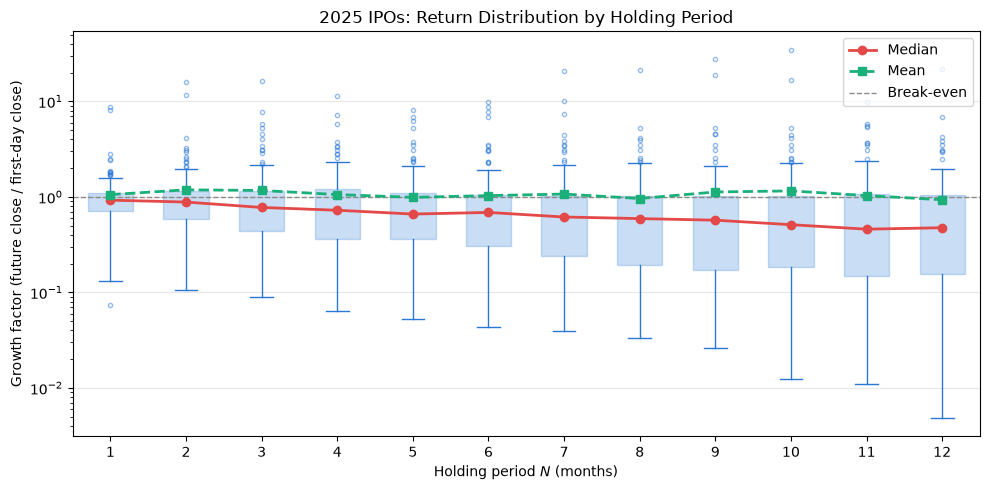

In [155]:
import matplotlib.pyplot as plt

months = range(1, 13)
box_data = [df_first_day[col].dropna() for col in future_growth_cols]
medians = df_first_day[future_growth_cols].median()
means = df_first_day[future_growth_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(
    box_data,
    positions=list(months),
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="#2a78d6", alpha=0.25, edgecolor="#2a78d6"),
    whiskerprops=dict(color="#2a78d6"),
    capprops=dict(color="#2a78d6"),
    medianprops=dict(linewidth=0),  # hidden: the red line below is the median trend
    flierprops=dict(marker="o", markersize=3, markerfacecolor="none", markeredgecolor="#2a78d6", alpha=0.5),
)

ax.plot(months, medians, color="#e34948", marker="o", linewidth=2, label=r"$\mathrm{Median}$", zorder=3)
ax.plot(months, means, color="#1baf7a", marker="s", linewidth=2, linestyle="--", label=r"$\mathrm{Mean}$", zorder=3)
ax.axhline(1.0, color="#8a8a86", linestyle="--", linewidth=1, label=r"$\mathrm{Break\text{-}even}$")

ax.set_yscale("log")
ax.set_xticks(list(months))
ax.set_xlabel(r"Holding period $N$ (months)")
ax.set_ylabel(r"Growth factor (future close / first-day close)")
ax.set_title(r"2025 IPOs: Return Distribution by Holding Period")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [156]:
fig.savefig(
    "ipo_holding_period_boxplot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

- **Observations**

**1. Trend of the median growth over time**

The median growth falls almost monotonically with the holding period: 0.92 at 1 month, 0.88 at 2, 0.77 at 3, 0.66 at 5, 0.59 at 8 and 0.48 at 12 months (only small bumps at 6 and 12 months). Every median is below 1, so at every horizon the typical 2025 IPO ended below its first-day close, and the longer it was held, the worse it got (about -52% after 12 months). For an investor, buying newly IPO'd stocks at the first-day close and holding them is a losing strategy for the typical stock, and the least bad option is to exit early. Note that the first-day close already includes the IPO "pop": investors who receive shares at the offer price are in a different position.

**2. Median vs mean**

The mean is above the median at every horizon, and the gap widens over time (0.13 at 1 month vs 0.46 at 12 months). The means stay around 1.0 (between 0.93 and 1.19), which would suggest a roughly break-even strategy, but they are driven by a few extreme winners (up to 34.7x at 10 months and 22x at 12 months), while 25% of the stocks end the 12 months below 0.15 of their first-day close. The mean therefore overstates what a typical IPO delivers, and the median is the better summary. The sample size is almost constant across horizons (131 stocks at 1 month, 129 at 12), so the trend is not an artifact of changing samples. However, the 15 tickers that could not be downloaded (probably delisted) are excluded, so the losses are likely understated (survivorship bias).

In [128]:
median_growth = df_first_day[future_growth_cols].median()

best_col = median_growth.idxmax()
best_months = int(best_col.split("_")[2])

print(f"Optimal holding period: {best_months} months | median growth: {median_growth.max():.4f}")

Optimal holding period: 1 months | median growth: 0.9234


> **Answer**: The optimal holding period is **1 month**, with a maximum median growth of about **0.92** (0.9234). Even at the best horizon, the typical stock ends about 8% below its first-day close.

## **Question 04**

- **Problem statement: What is the total profit (in $ thousands) you would have earned by investing $1000 every time a stock was oversold (RSI < 30)?**

### **Solution**

In [129]:
import gdown

file_id = "1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.parquet", quiet=False)

df = pd.read_parquet("data.parquet", engine="pyarrow")
df.shape

Downloading...
From (original): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-
From (redirected): https://drive.google.com/uc?id=1grCTCzMZKY5sJRtdbLVCXg8JXA8VPyg-&confirm=t&uuid=5acbf8e1-8e13-4a91-b117-d2dcb349f9fa
To: /home/lucas/github/courses/stock-markets-analytics-zoomcamp-2026/coursework/homeworks/module-02/data.parquet
100%|██████████| 130M/130M [00:04<00:00, 31.8MB/s] 


(229932, 203)

In [130]:
RSI_OVERSOLD_THRESHOLD = 30

df["rsi"].describe()

count    229470.000000
mean         52.972321
std          12.085901
min           0.000000
25%          44.535042
50%          53.066628
75%          61.511647
max         100.000000
Name: rsi, dtype: float64

In [131]:
is_oversold = df["rsi"] < RSI_OVERSOLD_THRESHOLD
is_in_window = (df["Date"] >= "2000-01-01") & (df["Date"] < "2025-06-01")

selected_df = df[is_oversold & is_in_window]
selected_df.shape

(5206, 203)

In [133]:
selected_df.head()

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
3562,24.252026,24.366965,22.451323,22.719513,151217800.0,0.0,0.0,MSFT,2000,2000-04-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3567,20.612310,20.842187,19.922679,20.420746,313645800.0,0.0,0.0,MSFT,2000,2000-04-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3667,21.052906,21.072063,20.133398,20.171711,78503000.0,0.0,0.0,MSFT,2000,2000-09-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3668,20.056772,20.114241,19.405453,19.673643,99915200.0,0.0,0.0,MSFT,2000,2000-09-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3669,19.692798,19.807736,19.060636,19.309669,69037800.0,0.0,0.0,MSFT,2000,2000-09-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
net_income = 1000 * (selected_df["growth_future_30d"] - 1).sum()

print(f"Number of trades: {len(selected_df)}")
print(f"Net income: ${net_income:,.2f}")
print(f"Net income (thousands): ${net_income / 1000:,.2f}k")

Number of trades: 5206
Net income: $65,805.59
Net income (thousands): $65.81k


- **Observations**

Average 30-day return per trade: 1.26%. Win rate (fraction of trades with a positive 30-day return): 55.13%. Both match the homework's stated benchmarks for the RSI < 30 threshold, confirming the filtering and profit calculation are correct.

> **Answer**: The net income earned by the RSI < 30 strategy (5,206 trades, 2000-01-01 to 2025-06-01) is about **$65.8 thousand** ($65,805.59).

## **Question 05**

- **Problem statement: How would you change the strategy if you want to increase profitability?**

### **Proposed strategy: using RSI states to time IPO entry**

Question 3 showed that buying every IPO at its first-day closing price produced
a negative median return at all holding horizons. Instead of entering every IPO
immediately, an alternative strategy is to wait until the stock reaches an
oversold state.

The RSI is divided into three interpretable states:

- **Oversold:** RSI < 30
- **Neutral:** 30 ≤ RSI ≤ 70
- **Overbought:** RSI > 70

A Markov transition matrix is used to estimate how IPOs move between these
states. The strategy then evaluates the 21-trading-day return after the first
oversold episode of each IPO and compares it with the original first-day entry.

#### **Prepare the DataFrame**

To analyze the same time-series from question 3, we use the `df_stocks`. First, we sort the values in order to get the transition between two consecutive trading days.

In [134]:
df_ipo_states = (
    df_stocks
    .reset_index()
    .copy()
)

df_ipo_states["Date"] = pd.to_datetime(df_ipo_states["Date"])

df_ipo_states = (
    df_ipo_states
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

df_ipo_states[["Date", "Ticker", "Close"]].head()

,Date,Ticker,Close
0,2025-01-24,AAPG,17.379999
1,2025-01-27,AAPG,17.250000
2,2025-01-28,AAPG,17.200001
3,2025-01-29,AAPG,17.330000
4,2025-01-30,AAPG,17.600000


#### **Evaluate the RSI for 14 trading days**

In [136]:
def calculate_rsi(close, period=14):
    delta = close.diff()

    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.ewm(
        alpha=1 / period,
        adjust=False,
        min_periods=period,
    ).mean()

    avg_loss = losses.ewm(
        alpha=1 / period,
        adjust=False,
        min_periods=period,
    ).mean()

    relative_strength = avg_gain / avg_loss

    return 100 - (100 / (1 + relative_strength))

In [137]:
df_ipo_states["rsi"] = (
    df_ipo_states
    .groupby("Ticker")["Close"]
    .transform(lambda close: calculate_rsi(close, period=14))
)

df_ipo_states["rsi"].describe()

count    42143.000000
mean        47.766849
std         14.307043
min          0.926555
25%         38.525495
50%         46.517008
75%         56.082144
max         98.486024
Name: rsi, dtype: float64

In [153]:
df_ipo_states["rsi"].head(15)

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10          NaN
11          NaN
12          NaN
13          NaN
14    36.145783
Name: rsi, dtype: float64

#### **Build RSI states**

In [138]:
df_ipo_states["rsi_state"] = pd.NA

has_rsi = df_ipo_states["rsi"].notna()

df_ipo_states.loc[has_rsi, "rsi_state"] = np.select(
    [
        df_ipo_states.loc[has_rsi, "rsi"] < 30,
        df_ipo_states.loc[has_rsi, "rsi"] > 70,
    ],
    [
        "Oversold",
        "Overbought",
    ],
    default="Neutral",
)

df_ipo_states["rsi_state"].value_counts()

rsi_state
Neutral       35156
Oversold       3791
Overbought     3196
Name: count, dtype: int64

#### **Find the next trading day**

In [139]:
df_ipo_states["next_rsi_state"] = (
    df_ipo_states
    .groupby("Ticker")["rsi_state"]
    .shift(-1)
)

#### **Daily transition matrix**

In [140]:
state_order = ["Oversold", "Neutral", "Overbought"]

valid_transitions = df_ipo_states.dropna(
    subset=["rsi_state", "next_rsi_state"]
)

transition_counts = pd.crosstab(
    valid_transitions["rsi_state"],
    valid_transitions["next_rsi_state"],
).reindex(
    index=state_order,
    columns=state_order,
    fill_value=0,
)

transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0,
)

display(transition_counts)
display(transition_matrix.round(4))

next_rsi_state,Oversold,Neutral,Overbought
rsi_state,,,
Oversold,3150,625,3
Neutral,584,33889,575
Overbought,4,601,2581


next_rsi_state,Oversold,Neutral,Overbought
rsi_state,,,
Oversold,0.8338,0.1654,0.0008
Neutral,0.0167,0.9669,0.0164
Overbought,0.0013,0.1886,0.8101


#### **Estimate the state after 21 trading days**

In [141]:
transition_matrix_21d = pd.DataFrame(
    np.linalg.matrix_power(
        transition_matrix.to_numpy(),
        21,
    ),
    index=state_order,
    columns=state_order,
)

transition_matrix_21d.round(4)

,Oversold,Neutral,Overbought
Oversold,0.0993,0.8324,0.0684
Neutral,0.0840,0.8432,0.0729
Overbought,0.0795,0.8390,0.0814


#### **Validate the 21-day Markov estimate against observed transitions**

In [148]:
df_ipo_states["observed_state_21d"] = (
    df_ipo_states
    .groupby("Ticker")["rsi_state"]
    .shift(-21)
)

observed_transition_21d = pd.crosstab(
    df_ipo_states["rsi_state"],
    df_ipo_states["observed_state_21d"],
    normalize="index",
).reindex(
    index=state_order,
    columns=state_order,
    fill_value=0,
)

display(observed_transition_21d.round(4))

markov_error = (
    transition_matrix_21d
    - observed_transition_21d
)

display(markov_error.round(4))

observed_state_21d,Oversold,Neutral,Overbought
rsi_state,,,
Oversold,0.2637,0.7268,0.0094
Neutral,0.0616,0.8908,0.0476
Overbought,0.0263,0.5996,0.3741


,Oversold,Neutral,Overbought
Oversold,-0.1644,0.1055,0.0589
Neutral,0.0224,-0.0476,0.0252
Overbought,0.0532,0.2394,-0.2927


#### **Visualize the 21 days matrix**

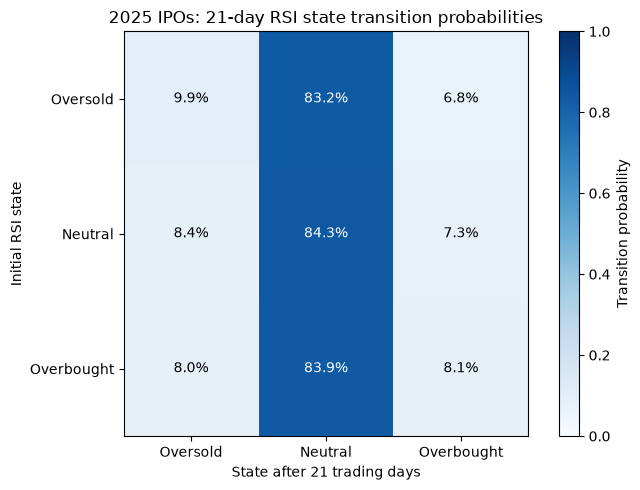

In [142]:
fig, ax = plt.subplots(figsize=(7, 5))

matrix_values = transition_matrix_21d.to_numpy()

image = ax.imshow(
    matrix_values,
    cmap="Blues",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(state_order)))
ax.set_xticklabels(state_order)

ax.set_yticks(range(len(state_order)))
ax.set_yticklabels(state_order)

ax.set_xlabel("State after 21 trading days")
ax.set_ylabel("Initial RSI state")
ax.set_title("2025 IPOs: 21-day RSI state transition probabilities")

for row in range(len(state_order)):
    for column in range(len(state_order)):
        value = matrix_values[row, column]

        ax.text(
            column,
            row,
            f"{value:.1%}",
            ha="center",
            va="center",
            color="white" if value > 0.5 else "black",
        )

fig.colorbar(image, ax=ax, label="Transition probability")
plt.tight_layout()
plt.show()

#### **Evaluate the future return after 21 days**

In [143]:
close_by_ticker = df_ipo_states.groupby("Ticker")["Close"]

df_ipo_states["future_growth_21d"] = (
    close_by_ticker.shift(-21)
    / df_ipo_states["Close"]
)

df_ipo_states["future_return_21d"] = (
    df_ipo_states["future_growth_21d"] - 1
)

#### **Identify the beggining of each oversold episode**

In [144]:
df_ipo_states["previous_rsi_state"] = (
    df_ipo_states
    .groupby("Ticker")["rsi_state"]
    .shift(1)
)

df_ipo_states["oversold_entry"] = (
    df_ipo_states["rsi_state"].eq("Oversold")
    & df_ipo_states["previous_rsi_state"]
        .fillna("Unknown")
        .ne("Oversold")
)

In [145]:
first_oversold_entries = (
    df_ipo_states[df_ipo_states["oversold_entry"]]
    .sort_values(["Ticker", "Date"])
    .drop_duplicates(subset="Ticker", keep="first")
)

first_oversold_entries[
    [
        "Ticker",
        "Date",
        "Close",
        "rsi",
        "future_growth_21d",
    ]
].head()

,Ticker,Date,Close,rsi,future_growth_21d
256,AAPG,2026-02-02,23.170000,29.220265,0.960293
424,AARD,2025-03-06,9.520000,17.202589,0.857143
828,ADVB,2025-04-07,58.000000,23.232104,0.568966
1324,AII,2025-11-20,18.253166,27.991257,1.092890
1625,AIRO,2025-11-04,14.270000,25.800999,0.672039


#### **Comparing strategies**

In [146]:
def summarize_growth(growth):
    growth = growth.dropna()

    return pd.Series(
        {
            "observations": len(growth),
            "mean_return_pct": (growth.mean() - 1) * 100,
            "median_return_pct": (growth.median() - 1) * 100,
            "win_rate_pct": (growth > 1).mean() * 100,
        }
    )

In [147]:
strategy_comparison = pd.DataFrame(
    {
        "First-day entry": summarize_growth(
            df_first_day["future_growth_1_m"]
        ),
        "First oversold episode": summarize_growth(
            first_oversold_entries["future_growth_21d"]
        ),
    }
).T

strategy_comparison.round(2)

,observations,mean_return_pct,median_return_pct,win_rate_pct
First-day entry,131.0,5.61,-7.66,38.17
First oversold episode,123.0,1.27,-3.28,42.28


#### **Fair comparison using the same IPOs**

In [ ]:
valid_oversold_entries = first_oversold_entries.dropna(
    subset=["future_growth_21d"]
)

eligible_tickers = valid_oversold_entries["Ticker"]

same_tickers_first_day = df_first_day[
    df_first_day["Ticker"].isin(eligible_tickers)
]["future_growth_1_m"]

fair_strategy_comparison = pd.DataFrame(
    {
        "First-day entry - same IPOs": summarize_growth(
            same_tickers_first_day
        ),
        "First oversold episode": summarize_growth(
            valid_oversold_entries["future_growth_21d"]
        ),
    }
).T

fair_strategy_comparison.round(2)

,observations,mean_return_pct,median_return_pct,win_rate_pct
First-day entry — same IPOs,123.0,4.96,-7.95,36.59
First oversold episode,123.0,1.27,-3.28,42.28


#### **Observations and conclusion**

For a fair comparison, both strategies were evaluated using the same 123 IPOs. Buying at the first-day close produced a mean return of 4.96%, a median return of -7.95%, and a 36.59% win rate. Waiting for the first oversold episode produced a mean return of 1.27%, a median return of -3.28%, and a 42.28% win rate.

Therefore, waiting for RSI < 30 improved the median result by 4.67 percentage points and increased the win rate by 5.69 percentage points. However, it reduced the mean return and the median remained negative. The RSI filter made the typical outcome less negative, but it did not demonstrate an overall increase in profitability.

The daily transition matrix showed strong persistence in RSI states. However, the 21-day Markov estimate did not closely reproduce the directly observed transitions. For example, the model estimated that only 9.9% of oversold observations would remain oversold after 21 trading days, while the observed proportion was 26.4%. For overbought observations, the corresponding values were 8.1% and 37.4%.

This indicates that a homogeneous first-order Markov chain loses state persistence too quickly and is not sufficient as a 21-day forecasting model. It also highlights that RSI normalization does not necessarily imply price recovery.

A more selective strategy could wait for RSI to recover above 30 instead of buying immediately when it falls below 30, and combine this confirmation with IPO characteristics, price momentum, volume, and the broader market regime. Any predictive model should be evaluated with a temporal train-test split, using future returns only as the target.